In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from plots import *
import seaborn as sns


In [2]:
data_fpath = Path('stable_scores.csv')
df = pd.read_csv(data_fpath)

df_ps_cols = pd.read_csv('df_ps_col_labels.csv')
ps_cols = df_ps_cols['ps'].values
df_ps_cols['label'] = (df_ps_cols['label']
                       .astype(str)
                       .str.replace('\r\n', '\n', regex=False)
                       .str.replace('\r', '\n', regex=False))
ps_cols_labels = dict(zip(df_ps_cols['ps'], df_ps_cols['label']))


figdir = Path('figs')
figdir.mkdir(parents=True, exist_ok=True)


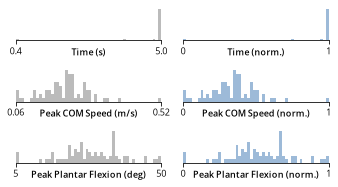

In [3]:
features = [
    ('rtt_time', 'Time', 's', '{:0.1f}'),
    ('rtt_peak_com_speed', 'Peak COM Speed', 'm/s', '{:0.2f}'),
    ('rtt_peak_pf', 'Peak Plantar Flexion', 'deg', '{:0.0f}'),
]

plt.figure(figsize=(4.8,2.7))
for i, (col, name, unit, fmt) in enumerate(features):
    values = df[col].dropna().values
    xmin, xmax = values.min(), values.max()
    XMIN, XMAX = (fmt.format(xmin)).replace('-', '–'), (fmt.format(xmax)).replace('-', '–')

    plt.subplot(3,2,i*2+1)
    plt.hist(values, bins=np.linspace(xmin, xmax, 51), color='#BBBBBB',  histtype='stepfilled', density=True)
    plt.yticks([])
    plt.xlim(xmin, xmax)
    plt.xticks([xmin, xmax], [XMIN, XMAX], fontdict={'fontsize':8.5})
    plt.xlabel(f'{name} ({unit})', fontdict={'weight':'semibold', 'fontsize':8.5}, labelpad=-8)
    sns.despine(left=True)

    plt.subplot(3,2,i*2+2)
    plt.hist(values, bins=np.linspace(xmin, xmax, 51), color=cp[1],  histtype='stepfilled', density=True)
    plt.yticks([])
    plt.xlim(xmin, xmax)
    plt.xticks([xmin, xmax], [0, 1], fontdict={'fontsize':8.5})
    plt.xlabel(f'{name} (norm.)', fontdict={'weight':'semibold', 'fontsize':8.5}, labelpad=-8)
    sns.despine(left=True)
plt.tight_layout()
plt.savefig(figdir / 'fig2a.pdf', dpi=300, transparent=True)
plt.show()


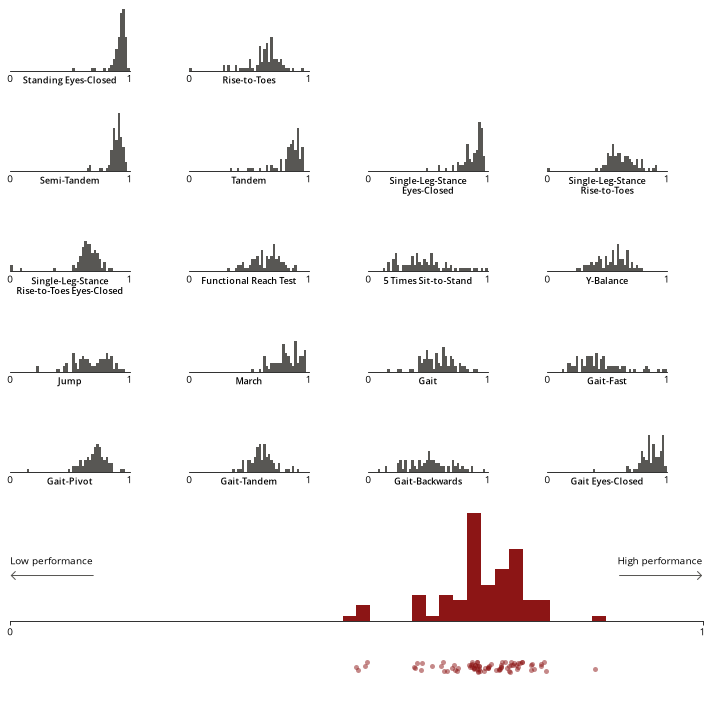

,task,min,max,mean,std
0,Standing Eyes-Closed,0.530646,0.983633,0.916039,0.066187
1,Rise-to-Toes,0.000000,0.947020,0.626194,0.143768
2,Semi-Tandem,0.641717,0.977179,0.887651,0.060466
3,Tandem,0.359901,0.952919,0.833213,0.122683
4,Single-Leg-Stance\nEyes-Closed,0.493903,0.969272,0.871464,0.095450
5,Single-Leg-Stance\nRise-to-Toes,0.000000,0.918626,0.619263,0.129477
6,Single-Leg-Stance\nRise-to-Toes Eyes-Closed,0.000000,0.848275,0.637794,0.140707
7,Functional Reach Test,0.325302,0.893591,0.640714,0.124577
8,5 Times Sit-to-Stand,0.137511,0.985690,0.466473,0.202381
9,Y-Balance,0.256728,0.781272,0.537178,0.127447


In [4]:
def add_hist(ax, series, xlabel, color, lw=2):
    ax.hist(series, bins=np.linspace(0, 1, 51), color=color,  histtype='stepfilled')
    ax.set_xlabel(xlabel, fontdict={'fontweight':'semibold', 'fontsize':9}, labelpad=-8, va='top')
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 1])
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(nrows=7, ncols=8, figure=fig,
              wspace=0,
              height_ratios=[1, 1, 1, 1, 1, 1.75, 0.75],
              width_ratios=[1, 0.5, 1, 0.5, 1, 0.5, 1, 0.3])

ymaxes = []
stats = []
for i, col in enumerate(ps_cols):
    j = i if i < 2 else i+2
    ax = fig.add_subplot(gs[j//4, j%4*2])
    add_hist(ax, df[col], ps_cols_labels[col], cp[-1], lw=1)
    ymaxes.append(plt.ylim()[1])
    stats.append({'task':ps_cols_labels[col], **df[col].agg(['min', 'max', 'mean', 'std'])})
ymax = np.max(ymaxes)
for ax in fig.get_axes():
    ax.set_ylim(0, ymax)
    ax.tick_params(length=0)

ax_big = fig.add_subplot(gs[-2, :])
add_hist(ax_big, df['stable_score'], None, cp[0])

ymax = plt.ylim()[1]
plt.annotate('Low performance', (0, ymax*0.5), ha='left')
plt.annotate('', xytext=(0.12, ymax*0.4), xy=(0, ymax*0.4),
             arrowprops=dict(arrowstyle='->', mutation_scale=10, mutation_aspect=2,
                             shrinkA=0, shrinkB=0, color=cp[-1]))
plt.annotate('High performance', (1, ymax*0.5), ha='right')
plt.annotate('', xytext=(0.88, ymax*0.4), xy=(1, ymax*0.4),
             arrowprops=dict(arrowstyle='->', mutation_scale=10, mutation_aspect=2,
                             shrinkA=0, shrinkB=0, color=cp[-1]))

ax_big = fig.add_subplot(gs[-1, :])
sns.stripplot(df, x='stable_score', alpha=0.5)


ss = df['stable_score'].values
xlines = np.array([ss.min(), ss.mean()-ss.std(), ss.mean(), ss.mean()+ss.std(), ss.max()])
plt.vlines(xlines, -0.25, -0.5, color=cp[-1])
plt.annotate('', xytext=(xlines[2], -0.375), xy=(xlines[1], -0.375),
             arrowprops=dict(arrowstyle='->', mutation_scale=10, mutation_aspect=2,
                             shrinkA=0, shrinkB=0, color=cp[-1]))
plt.annotate('', xytext=(xlines[2], -0.375), xy=(xlines[3], -0.375),
             arrowprops=dict(arrowstyle='->', mutation_scale=10, mutation_aspect=2,
                             shrinkA=0, shrinkB=0, color=cp[-1]))
plt.annotate(f'Min: {ss.min():0.2f}', (xlines[0], -0.75), ha='center', va='bottom',
             fontsize=9, fontweight='semibold')
plt.annotate(f'Std: {ss.std():0.2f}', (xlines[1], -0.75), ha='center', va='bottom',
             fontsize=9, fontweight='semibold')
plt.annotate(f'Mean: {ss.mean():0.2f}', (xlines[2], -0.75), ha='center', va='bottom',
             fontsize=9, fontweight='semibold')
plt.annotate(f'Max: {ss.max():0.2f}', (xlines[4], -0.75), ha='center', va='bottom',
             fontsize=9, fontweight='semibold')

plt.xlim(0, 1)
plt.ylim(-0.75, 0.2)
plt.xticks([])
plt.yticks([])
plt.xlabel(None)
sns.despine(bottom=True, left=True, ax=ax_big)

plt.tight_layout()
fig.savefig(figdir / 'fig2bc.pdf', dpi=300, transparent=True)
plt.show()

pd.DataFrame(stats)
